In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
# Load the data to examine its structure
file_path = '/content/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnetAll_WHOI2014_stage1_results.csv'

df = pd.read_csv(file_path)
df['per_class_accuracy'] = df['per_class_accuracy']/100
# Display the first few rows of the dataframe to understand its structure
df.head()

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type
0,resnet18,CrossEntropyLoss(),adam,step,0.000001,512,0.954227,0.005395,1816.090624,7137.868661,"{'train_loss': [0.2689166330974463, 0.18213335...",lightgreen,18
1,resnet50,CrossEntropyLoss(),adam,step,0.000001,512,0.952205,0.005586,4098.432512,8265.197833,"{'train_loss': [0.2996703496625234, 0.20839150...",mediumseagreen,50
2,resnet152,CrossEntropyLoss(),adam,step,0.000001,512,0.952889,0.005383,11534.315010,15080.444320,"{'train_loss': [0.31627048507683064, 0.2180064...",darkgreen,152


# Stage 1 

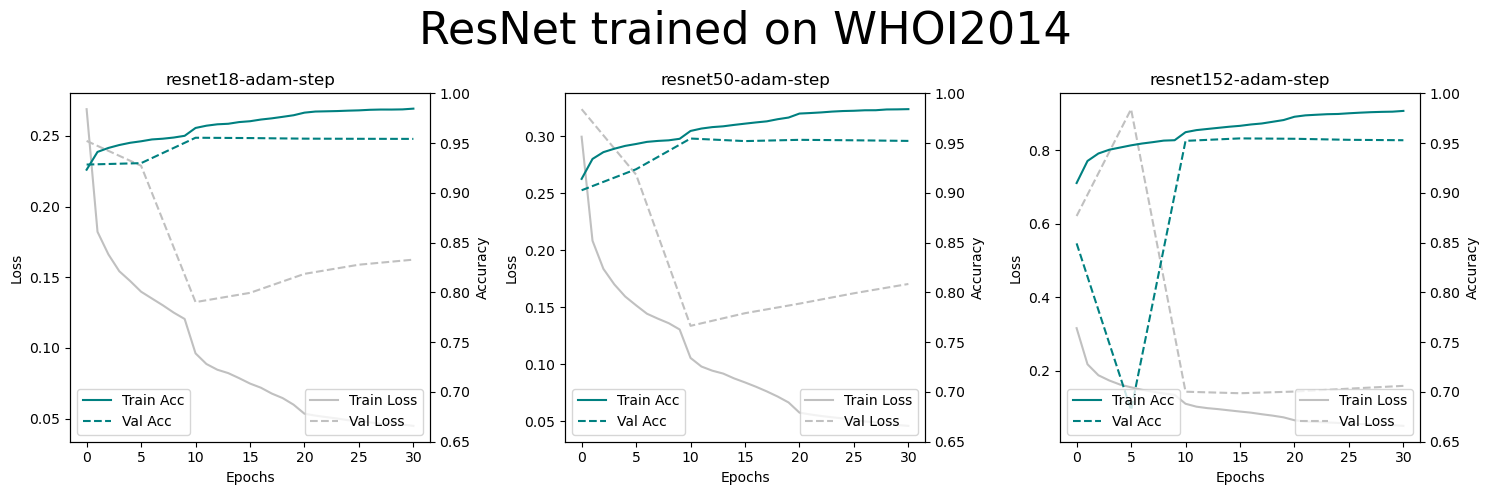

In [4]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
# Plot Accuracy and Loss
for i, ax in zip(range(len(df)), axes):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.set_ylim([0.65, 1])
  ax2.legend(loc='lower left')
  ax.legend(loc='lower right')
  opt = df["optimizer"][i]
  sched = df["scheduler"][i]
  ax.set_title(f"{model_name}-{opt}-{sched}")

plt.suptitle("ResNet trained on WHOI2014", fontsize=32)
plt.tight_layout()
plt.show()

# Stage 2 - Freeze


In [23]:
file_path_s2 = '/Users/birdy/Documents/mit-meng-thesis/results/ResnetAll_WHOI2014_stage2_results.csv'
df_s2 = pd.read_csv(file_path_s2)
df_s2["size_marker"] = df_s2["MACs"]/2
df_s2

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18-freeze,cross_entropy,adam,step,0.000001,512,0.927205,0.325432,1816.090624,6747.738619,"{'train_loss': [0.4934928347178611, 0.29901724...",lightgreen,18.0,908.045312
1,resnet50-freeze,cross_entropy,adam,step,0.000001,512,0.932832,0.336201,4098.432512,7233.520846,"{'train_loss': [0.44297492692417806, 0.2736215...",mediumseagreen,50.0,2049.216256
2,resnet152-freeze,cross_entropy,adam,step,0.000001,512,0.930900,0.338511,11534.315010,8974.588055,"{'train_loss': [0.4320261203200752, 0.27249452...",darkgreen,152.0,5767.157505
3,resnet18-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,512,0.950456,0.304654,1816.090624,7808.043691,"{'train_loss': [0.42096526740619894, 0.2756543...",lightgreen,18.0,908.045312
4,resnet18-WHOI2014-dropout0.3,cross_entropy,adam,step,0.000001,512,0.950350,0.289249,1816.090624,7859.801296,"{'train_loss': [0.4213280254920734, 0.27834512...",lightgreen,18.0,908.045312
5,resnet18-WHOI2014-dropout0.5,cross_entropy,adam,step,0.000001,512,0.949939,0.287226,1816.090624,7829.948472,"{'train_loss': [0.41100950706580874, 0.2745918...",lightgreen,18.0,908.045312
6,TEMP-resnet50-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,256,0.936107,0.145113,11534.315010,19143.745450,"{'train_loss': [0.6977349471025382, 0.42362719...",NaN,NaN,5767.157505
7,TEMP-resnet50-WHOI2014-dropout0.3,cross_entropy,adam,step,0.000001,256,0.941084,0.160256,11534.315010,19102.262500,"{'train_loss': [0.7280070153042278, 0.44110746...",NaN,NaN,5767.157505
8,TEMP-resnet50-WHOI2014-dropout0.5,cross_entropy,adam,step,0.000001,256,0.932485,0.140030,11534.315010,19087.253170,"{'train_loss': [0.7635995842240796, 0.46735787...",NaN,NaN,5767.157505
9,resnet152-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,256,0.931068,0.145113,11534.315010,19143.745450,"{'train_loss': [0.6977349471025382, 0.42362719...",NaN,NaN,5767.157505


In [6]:
df["size_marker"] = df["MACs"]/2

In [7]:
df

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18,CrossEntropyLoss(),adam,step,0.000001,512,0.954227,0.005395,1816.090624,7137.868661,"{'train_loss': [0.2689166330974463, 0.18213335...",lightgreen,18,908.045312
1,resnet50,CrossEntropyLoss(),adam,step,0.000001,512,0.952205,0.005586,4098.432512,8265.197833,"{'train_loss': [0.2996703496625234, 0.20839150...",mediumseagreen,50,2049.216256
2,resnet152,CrossEntropyLoss(),adam,step,0.000001,512,0.952889,0.005383,11534.315010,15080.444320,"{'train_loss': [0.31627048507683064, 0.2180064...",darkgreen,152,5767.157505


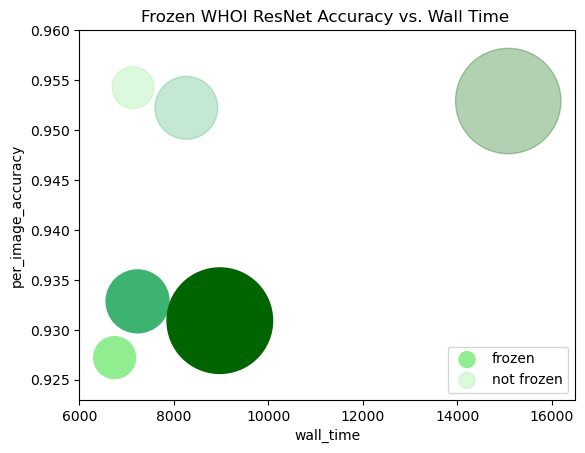

In [8]:
# plot resnet18-freeze, 50, 152 per_image_accuracy vs wall_time
fig, ax = plt.subplots()
df_s2.iloc[:3].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=1, color=df_s2.iloc[:3]["color"], label="frozen")
df.plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=0.3, color=df["color"], label="not frozen")
ax.set_xlim([6000, 16500])
ax.set_ylim([0.923, 0.96])
ax.legend(loc="lower right", markerscale=0.2)
ax.set_title("Frozen WHOI ResNet Accuracy vs. Wall Time ")
plt.show()

# Stage 2 - Dropout

In [24]:
df_s2

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18-freeze,cross_entropy,adam,step,0.000001,512,0.927205,0.325432,1816.090624,6747.738619,"{'train_loss': [0.4934928347178611, 0.29901724...",lightgreen,18.0,908.045312
1,resnet50-freeze,cross_entropy,adam,step,0.000001,512,0.932832,0.336201,4098.432512,7233.520846,"{'train_loss': [0.44297492692417806, 0.2736215...",mediumseagreen,50.0,2049.216256
2,resnet152-freeze,cross_entropy,adam,step,0.000001,512,0.930900,0.338511,11534.315010,8974.588055,"{'train_loss': [0.4320261203200752, 0.27249452...",darkgreen,152.0,5767.157505
3,resnet18-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,512,0.950456,0.304654,1816.090624,7808.043691,"{'train_loss': [0.42096526740619894, 0.2756543...",lightgreen,18.0,908.045312
4,resnet18-WHOI2014-dropout0.3,cross_entropy,adam,step,0.000001,512,0.950350,0.289249,1816.090624,7859.801296,"{'train_loss': [0.4213280254920734, 0.27834512...",lightgreen,18.0,908.045312
5,resnet18-WHOI2014-dropout0.5,cross_entropy,adam,step,0.000001,512,0.949939,0.287226,1816.090624,7829.948472,"{'train_loss': [0.41100950706580874, 0.2745918...",lightgreen,18.0,908.045312
6,TEMP-resnet50-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,256,0.936107,0.145113,11534.315010,19143.745450,"{'train_loss': [0.6977349471025382, 0.42362719...",NaN,NaN,5767.157505
7,TEMP-resnet50-WHOI2014-dropout0.3,cross_entropy,adam,step,0.000001,256,0.941084,0.160256,11534.315010,19102.262500,"{'train_loss': [0.7280070153042278, 0.44110746...",NaN,NaN,5767.157505
8,TEMP-resnet50-WHOI2014-dropout0.5,cross_entropy,adam,step,0.000001,256,0.932485,0.140030,11534.315010,19087.253170,"{'train_loss': [0.7635995842240796, 0.46735787...",NaN,NaN,5767.157505
9,resnet152-WHOI2014-dropout0.1,cross_entropy,adam,step,0.000001,256,0.931068,0.145113,11534.315010,19143.745450,"{'train_loss': [0.6977349471025382, 0.42362719...",NaN,NaN,5767.157505


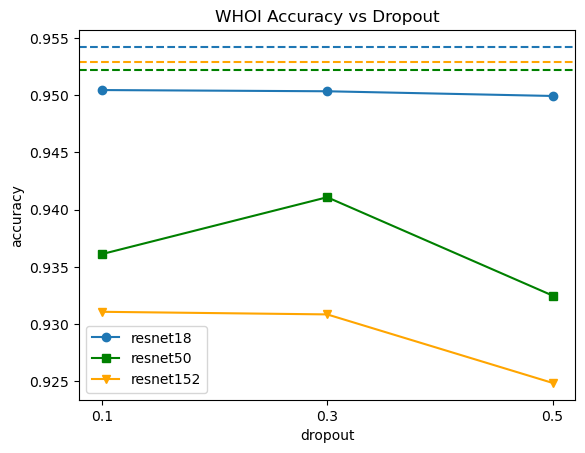

In [27]:
fig, ax = plt.subplots()
dropouts = [0.1, 0.3, 0.5]
ax.plot(dropouts, df_s2.loc[3:5]['per_image_accuracy'], marker='o', label="resnet18")
ax.plot(dropouts, df_s2.loc[6:8]['per_image_accuracy'], marker='s', label="resnet50", color='green')
ax.plot(dropouts, df_s2.loc[9:11]['per_image_accuracy'], marker='v', label="resnet152", color="orange")
ax.axhline(df.loc[0]['per_image_accuracy'], color='tab:blue', linestyle='--')
ax.axhline(df.loc[1]['per_image_accuracy'], color='green', linestyle='--')
ax.axhline(df.loc[2]['per_image_accuracy'], color='orange', linestyle='--')
ax.set_xticks([0.1, 0.3, 0.5])
ax.set_ylabel("accuracy")
ax.set_xlabel("dropout")
ax.legend()
ax.set_title("WHOI Accuracy vs Dropout")
plt.show()

# Stage 3 - Augmentations

In [28]:

file_path_s3 = '/Users/birdy/Documents/mit-meng-thesis/results/ResnetAll_WHOI2014_stage3_results.csv'
df_s3 = pd.read_csv(file_path_s3)
df_s3["size_marker"] = df_s3["MACs"]/2

In [29]:
df_s3

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,size_marker
0,resnet18-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.947597,0.400281,1816.090624,7140.778560,"{'train_loss': [0.27381146976476806, 0.1992798...",908.045312
1,resnet18-WHOI2014-train_augmix,cross_entropy,adam,step,0.000001,512,0.954897,0.401598,1816.090624,48997.102580,"{'train_loss': [0.3176988322142156, 0.24254328...",908.045312
2,resnet50-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.950897,0.384236,4098.432512,9157.508565,"{'train_loss': [0.3087030302730228, 0.22083314...",2049.216256
3,resnet50-WHOI2014-train_augmix,cross_entropy,adam,step,0.000001,512,0.953786,0.373781,4098.432512,41533.949750,"{'train_loss': [0.36001100040174183, 0.2718978...",2049.216256
4,resnet152-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.950380,0.382919,11534.315010,14624.394420,"{'train_loss': [0.30830749692972564, 0.2289849...",5767.157505
5,resnet152-WHOI2014-train_augmix,cross_entropy,adam,step,0.000001,512,0.000198,0.012346,11534.315010,43690.950490,"{'train_loss': [0.3928029238531827, 0.29005539...",5767.157505


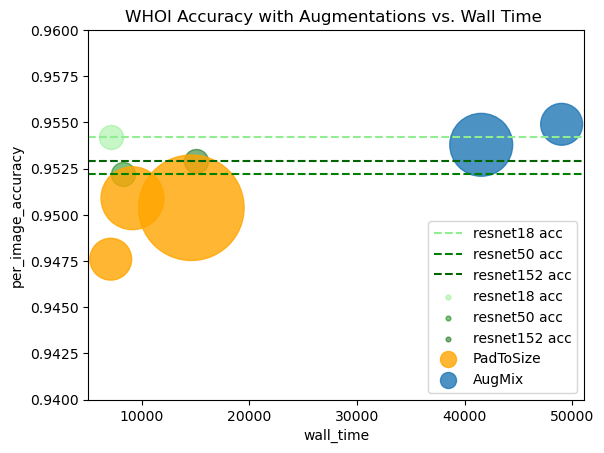

In [54]:
pad_idxs = [0, 2, 4]
aug_idxs = [1, 3, 5]
# plot resnet18-freeze, 50, 152 per_image_accuracy vs wall_time
fig, ax = plt.subplots()

# Plain ResNet Accuracy
ax.axhline(df.loc[0]['per_image_accuracy'], color='lightgreen', linestyle='--', label="resnet18 acc")
ax.axhline(df.loc[1]['per_image_accuracy'], color='green', linestyle='--', label="resnet50 acc")
ax.axhline(df.loc[2]['per_image_accuracy'], color='darkgreen', linestyle='--', label="resnet152 acc")

ax.scatter(df.loc[0]['wall_time'], df.loc[0]['per_image_accuracy'], s=300, alpha = 0.5, color='lightgreen', label="resnet18 acc")
ax.scatter(df.loc[1]['wall_time'], df.loc[1]['per_image_accuracy'], s=300,alpha = 0.5, color='green', label="resnet50 acc")
ax.scatter(df.loc[2]['wall_time'], df.loc[2]['per_image_accuracy'], s=300, alpha = 0.5, color='darkgreen', label="resnet152 acc")

df_s3.iloc[pad_idxs].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=.8, color='orange', label="PadToSize")
df_s3.iloc[aug_idxs].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=.8, color='tab:blue', label="AugMix")
# df.plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=0.3, color='green', label="No Aug")
# ax.set_xlim([6000, 16500])

ax.set_ylim([0.94, 0.96])
ax.legend(loc="lower right", markerscale=0.2)
ax.set_title("WHOI Accuracy with Augmentations vs. Wall Time ")
plt.show()

## Single Plots 

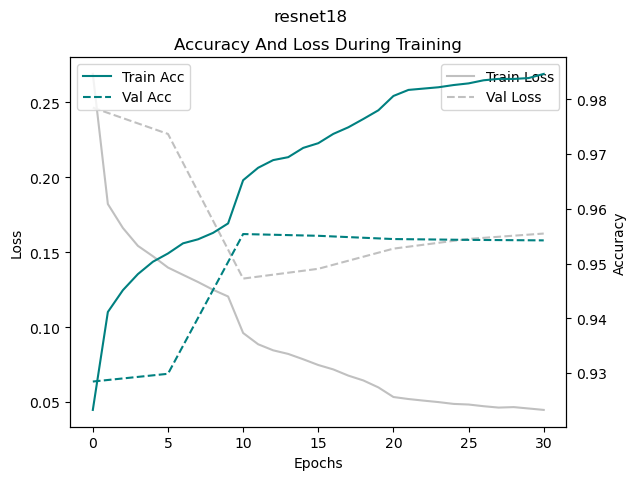

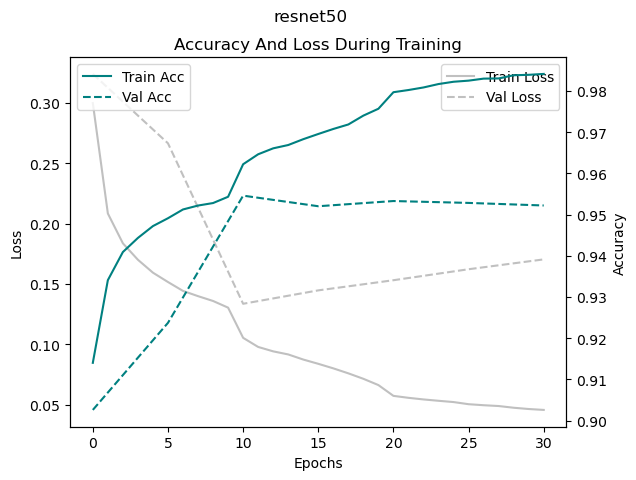

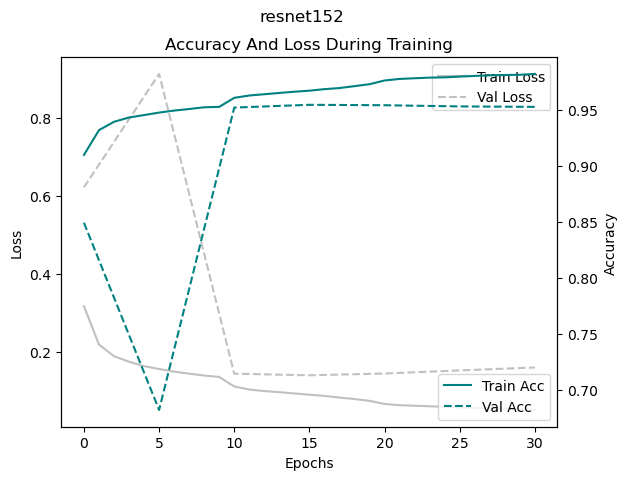

In [8]:
# Plot Accuracy and Loss
for i in range(len(df)):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  fig, ax = plt.subplots()
  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax.legend()
  plt.suptitle(f"{model_name}")
  plt.show()

# Model Comparison Plots

## Accuracy of models

In [ ]:
df[['model_name', 'per_image_accuracy']].sort_values(by='per_image_accuracy', ascending=False)

,model_name,per_image_accuracy
7,resnet18-UH-adam-step-CrossEntropyLoss(),0.790130
6,resnet18-UH-adam-step-CrossEntropyLoss(),0.788898
3,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.787817
12,resnet18-UH-adamw-step-CrossEntropyLoss(),0.786946
0,resnet18-UH-sgd-step-CrossEntropyLoss(),0.784903
2,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.782921
9,resnet18-UH-adam-cos-CrossEntropyLoss(),0.780728
8,resnet18-UH-adam-cos-CrossEntropyLoss(),0.777905
15,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772708
14,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772528


## Per-Image vs Per-Class

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


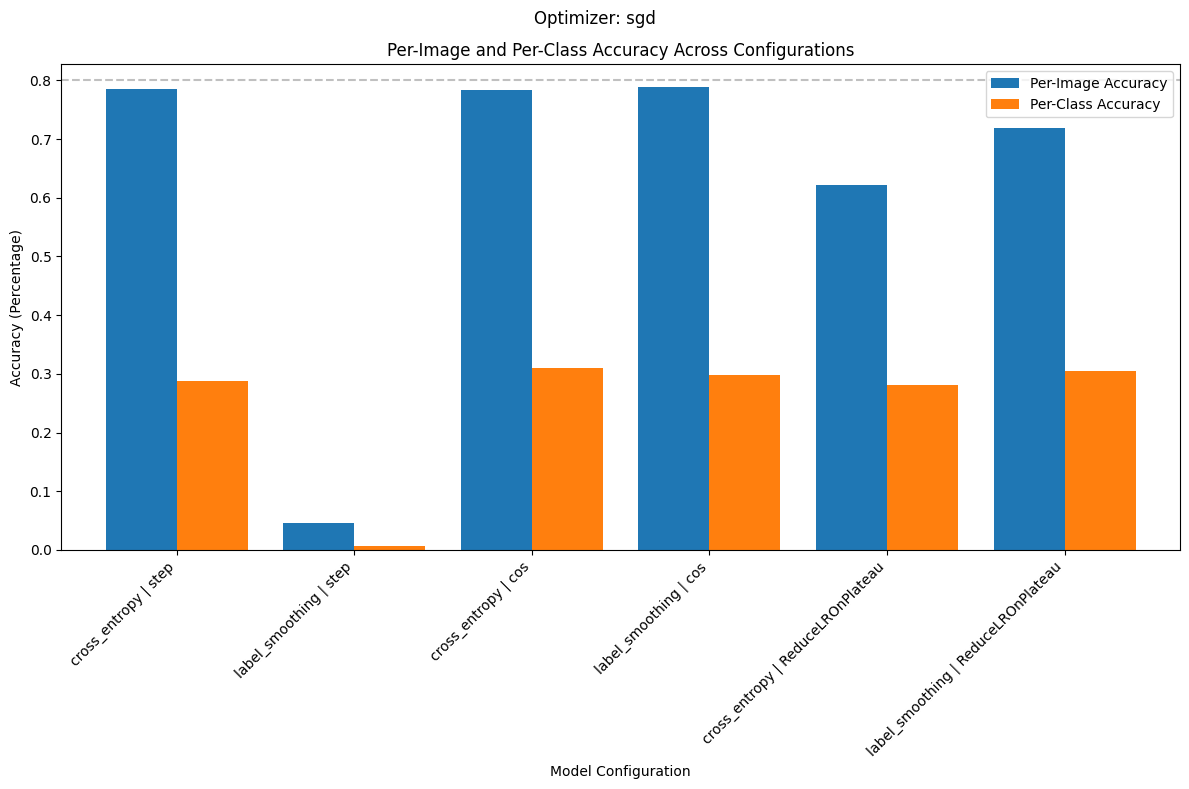

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


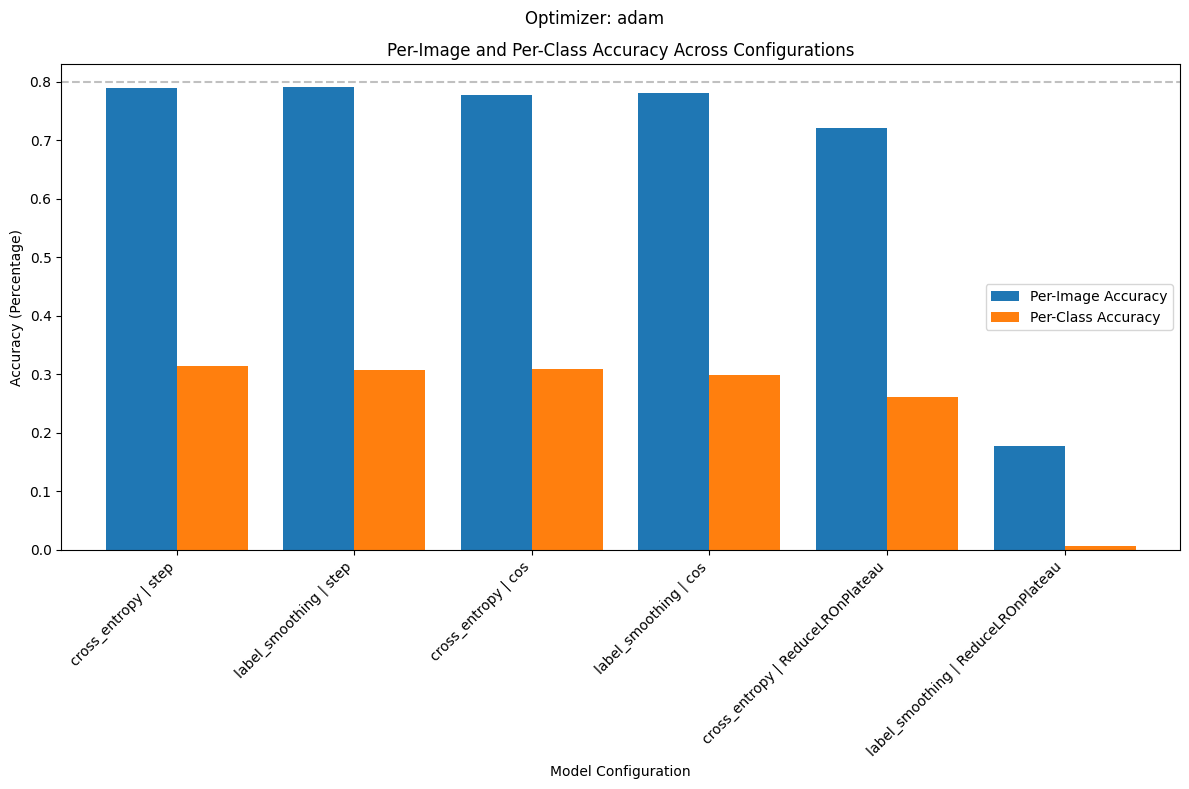

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


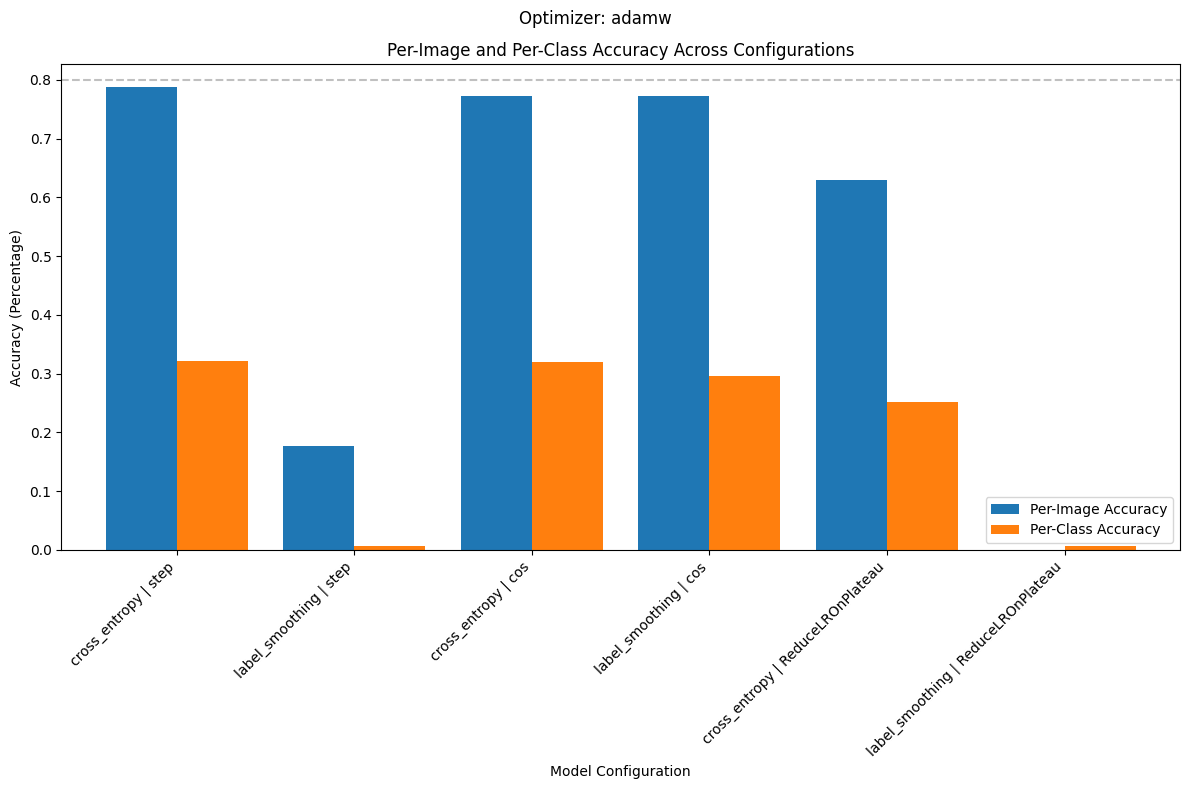

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','per_image_accuracy', 'per_class_accuracy']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Per-Image and Per-Class Accuracy Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("Accuracy (Percentage)")
  plt.xticks(rotation=45, ha="right")
  plt.legend(["Per-Image Accuracy", "Per-Class Accuracy"])
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()


## Wall Time

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


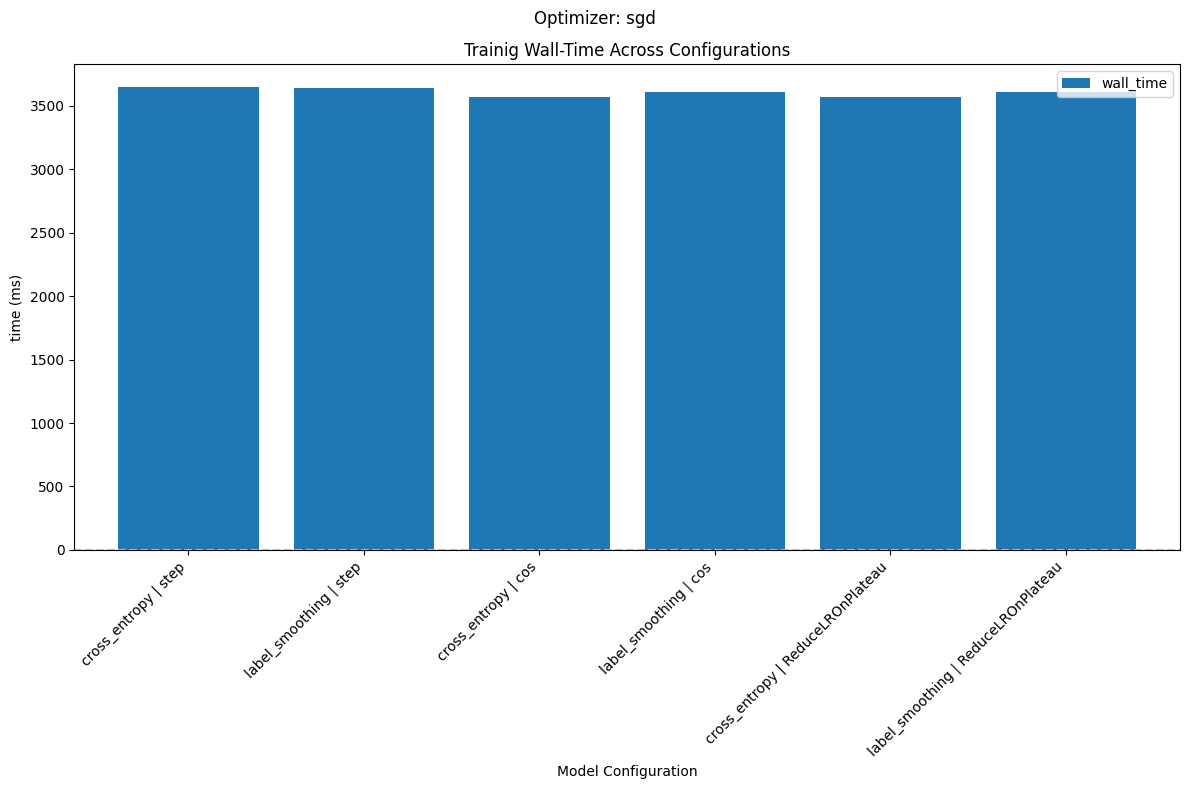

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


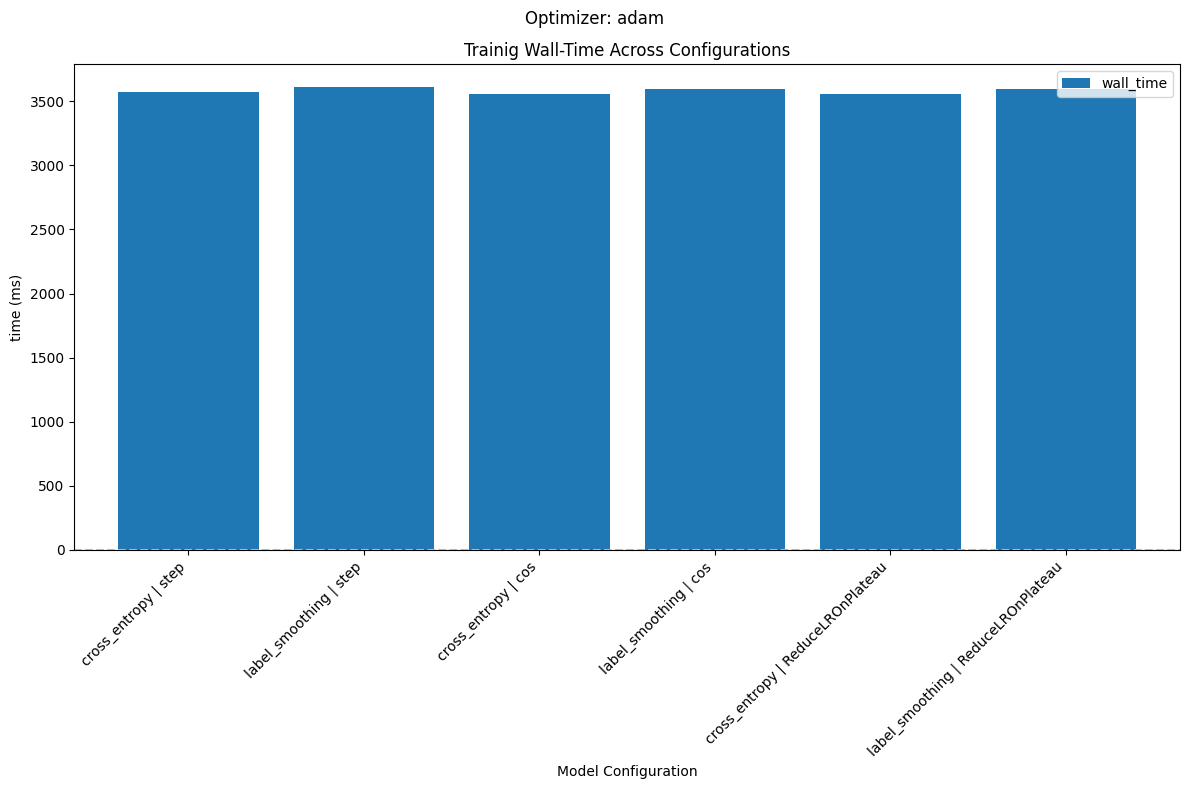

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


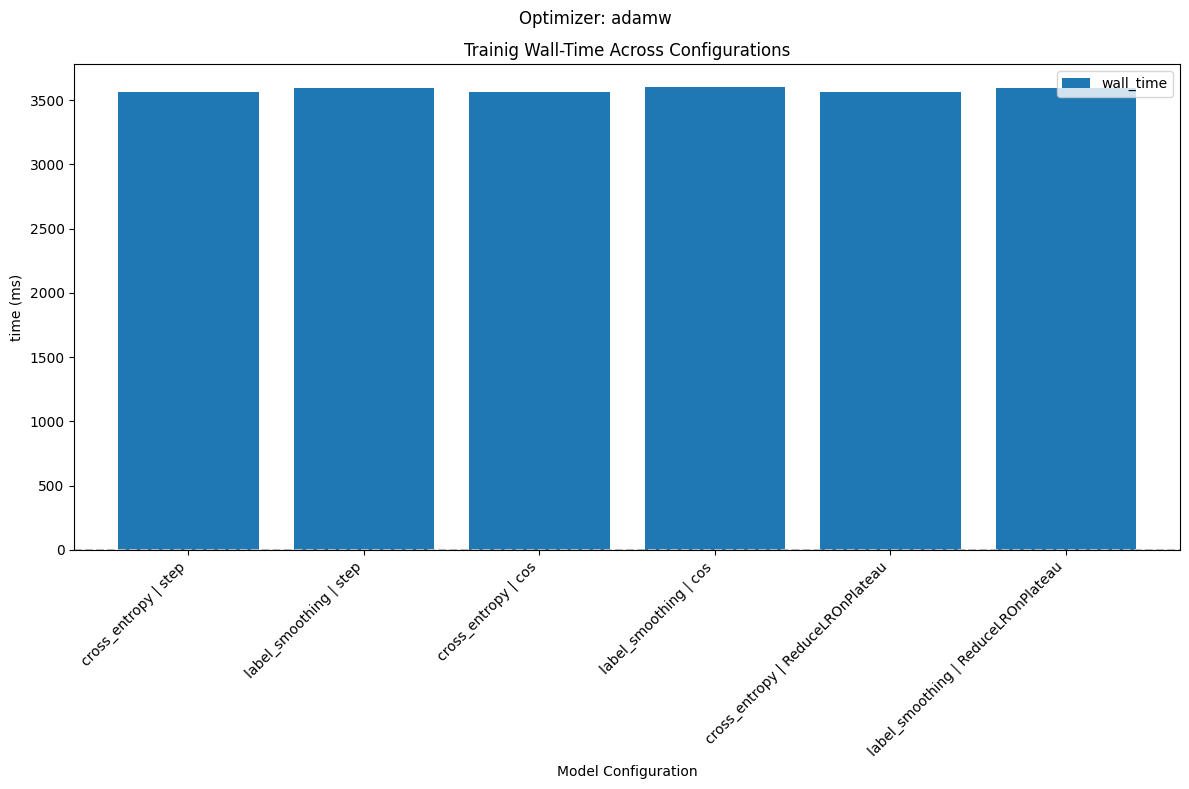

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','wall_time']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Trainig Wall-Time Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("time (ms)")
  plt.xticks(rotation=45, ha="right")
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()